In [1]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


Yorum dosyası okundu.
Toplam yorum: 2914


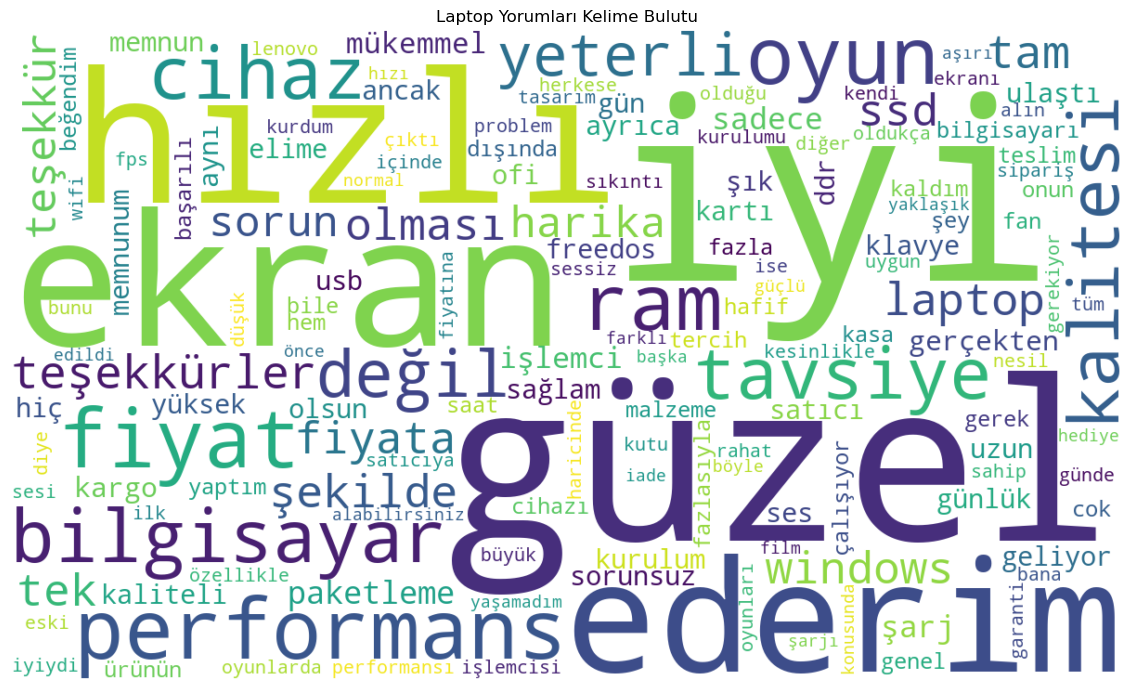

Kelime bulutu oluşturuldu:
grafikler/kelime_bulutu.png
En sık geçen kelimeler dosyası oluşturuldu:
en_sik_gecen_kelimeler.xlsx

En sık geçen ilk 10 kelime:
       kelime  frekans
0         iyi      902
1       güzel      706
2       ekran      454
3       hızlı      444
4      ederim      428
5  performans      427
6       fiyat      411
7        oyun      403
8         ram      383
9  bilgisayar      343


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re
import os

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "temiz_laptop_yorumlari.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)

df = pd.read_excel(GIRIS_DOSYASI)

print("Yorum dosyası okundu.")
print("Toplam yorum:", len(df))


# ==============================
# STOPWORDS
# ==============================

stopwords = set([
    "ve", "veya", "ile", "ama", "fakat", "çünkü", "için",
    "bir", "bu", "şu", "o", "çok", "daha", "en", "da", "de",
    "mi", "mı", "mu", "mü", "gibi", "olarak", "var", "yok",
    "ben", "sen", "biz", "siz", "onlar", "ürün", "ürünü",
    "aldım", "aldık", "geldi", "göre", "kadar", "sonra",
    "henüz", "şimdilik", "gayet", "bence", "biraz", "zaten",
    "olan", "oldu", "oluyor", "ettim", "ediyorum", "kullanıyorum",
    "kullanım", "kullanmak", "kullandım", "hepsiburada"
])


# ==============================
# METİN TEMİZLEME
# ==============================

def temizle(metin):
    metin = str(metin).lower()
    metin = re.sub(r"[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]", " ", metin)
    metin = re.sub(r"\s+", " ", metin)
    return metin.strip()


tum_metin = " ".join(df["yorum_metni"].dropna().astype(str))
tum_metin = temizle(tum_metin)

kelimeler = tum_metin.split()

temiz_kelimeler = [
    kelime for kelime in kelimeler
    if kelime not in stopwords and len(kelime) > 2
]

temiz_metin = " ".join(temiz_kelimeler)


# ==============================
# KELİME BULUTU
# ==============================

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False
).generate(temiz_metin)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Laptop Yorumları Kelime Bulutu")
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/kelime_bulutu.png", dpi=300)
plt.show()


# ==============================
# EN SIK GEÇEN KELİMELER
# ==============================

kelime_sayilari = Counter(temiz_kelimeler)

en_sik = kelime_sayilari.most_common(30)

en_sik_df = pd.DataFrame(
    en_sik,
    columns=["kelime", "frekans"]
)

en_sik_df.to_excel(
    "en_sik_gecen_kelimeler.xlsx",
    index=False
)

print("Kelime bulutu oluşturuldu:")
print(f"{CIKTI_KLASORU}/kelime_bulutu.png")

print("En sık geçen kelimeler dosyası oluşturuldu:")
print("en_sik_gecen_kelimeler.xlsx")

print("\nEn sık geçen ilk 10 kelime:")
print(en_sik_df.head(10))